In [13]:
while True:
  print("1. Addition")
  print("2. Subtraction")
  print("3. Multiplication")
  print("4. Division")
  print("5. Exit")

  choice = int(input("Enter your choice: "))

  if choice == 5:
    print("Calculator closed")
    break

  num1 = float(input("Enter the first number: "))
  num2 = float(input("Enter the second number: "))

  if choice == 1:
    print("Result:", num1 + num2)
  elif choice == 2:
    print("Result:", num1 - num2)
  elif choice == 3:
    print("Result:", num1 * num2)
  elif choice == 4:
    if num2 != 0:
      print("Result:", num1 / num2)
    else:
      print("Error: Cannot divide by zero.")
  else:
    print("Invalid choice")

1. Addition
2. Subtraction
3. Multiplication
4. Division
5. Exit
Enter your choice: 1
Enter the first number: 23
Enter the second number: 12
Result: 35.0
1. Addition
2. Subtraction
3. Multiplication
4. Division
5. Exit
Enter your choice: 5
Calculator closed


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/content/titanic.csv')
df.head() #first few rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
df.head() #first few rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df.shape

(891, 12)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [18]:
df.duplicated().value_counts()

,count
False,891


In [19]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [20]:
missing= df.isnull().sum()

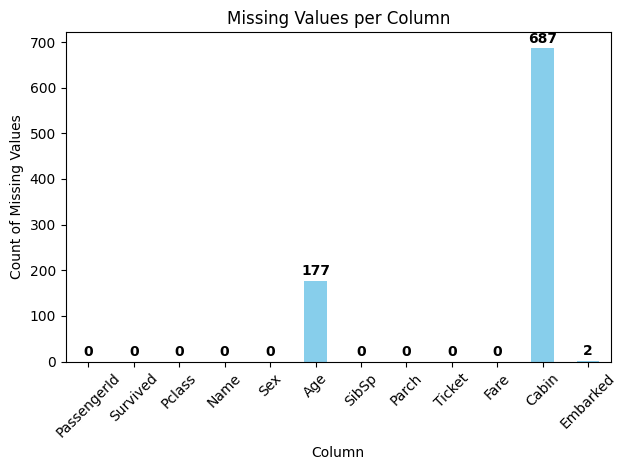

In [22]:

ax= missing.plot(kind='bar', color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=4)

for index, value in enumerate(missing):
    plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

In [29]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [30]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [31]:
survival_counts = df['Survived'].value_counts()

print("Survival Counts:\n", survival_counts)

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64


/tmp/ipykernel_6174/2424611426.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pink')


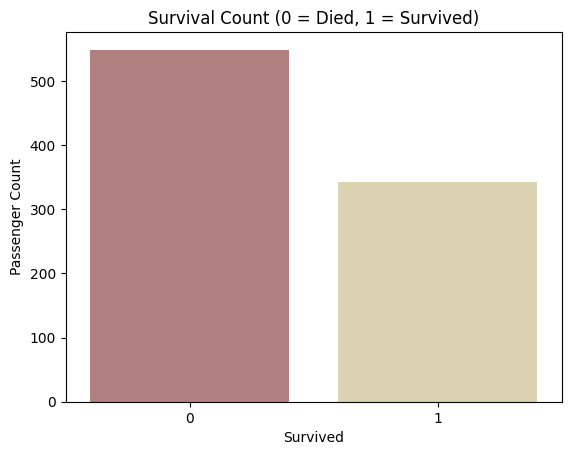

In [34]:
sns.countplot(x='Survived', data=df, palette='pink')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.show()

In [35]:
gender_counts = df['Sex'].value_counts()
print("\nGender Counts:\n", gender_counts)


Gender Counts:
 Sex
male      577
female    314
Name: count, dtype: int64


In [36]:
survival_by_gender = df.groupby(['Sex', 'Survived']).size()
print("\nSurvival by Gender:\n", survival_by_gender)


Survival by Gender:
 Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


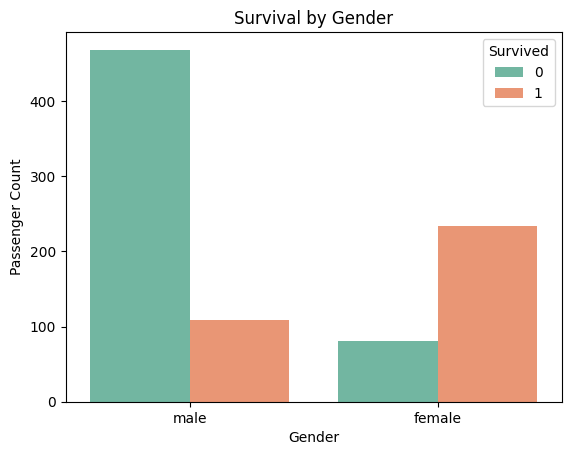

In [42]:
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

In [43]:
pclass_counts = df['Pclass'].value_counts()
print("\nPassenger Class Counts:\n", pclass_counts)


Passenger Class Counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64


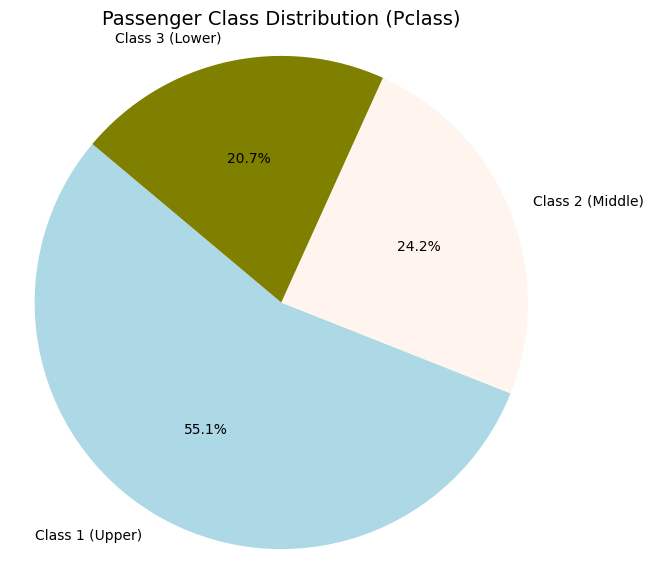

In [44]:
labels = ['Class 1 (Upper)', 'Class 2 (Middle)', 'Class 3 (Lower)']
plt.figure(figsize=(7, 7))
plt.pie(pclass_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightblue', 'seashell', 'olive'])
plt.title('Passenger Class Distribution (Pclass)', fontsize=14)
plt.axis('equal')
plt.show()

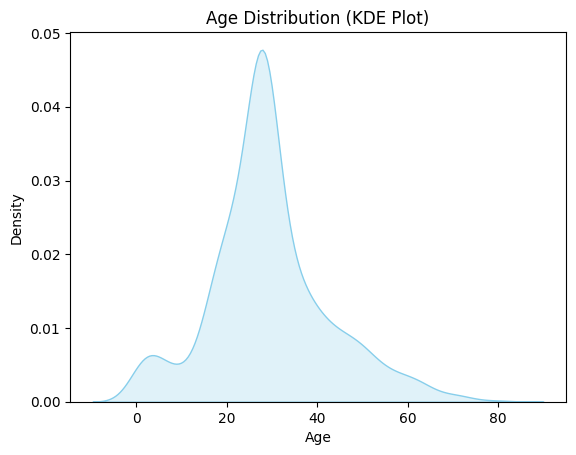

In [45]:
sns.kdeplot(df['Age'], fill=True, color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

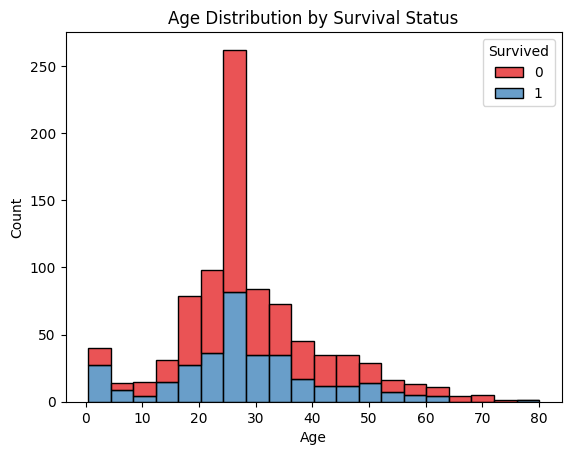

In [46]:
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=20, palette='Set1')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()